In [4]:
import pandas as pd

df = pd.read_csv('marketing_data.csv')
df = df.drop_duplicates().dropna()
print(df.info())

# Let's look at the first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  object 
 1   StartDate    10000 non-null  object 
 2   EndDate      10000 non-null  object 
 3   Channel      10000 non-null  object 
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB
None


,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [2]:
channel_perf = df.groupby('Channel')[['Cost_USD', 'Revenue_USD']].sum().reset_index()

#  Calculate the true ROI Percentage for each channel
# Formula: ((Revenue - Cost) / Cost) * 100
channel_perf['ROI_Percentage'] = ((channel_perf['Revenue_USD'] - channel_perf['Cost_USD']) / channel_perf['Cost_USD']) * 100

channel_perf = channel_perf.sort_values(by='ROI_Percentage', ascending=False)

#  Display the results!
print("--- MARKETING CHANNEL ROI ANALYSIS ---")
print(channel_perf.round(2))

--- MARKETING CHANNEL ROI ANALYSIS ---
      Channel    Cost_USD  Revenue_USD  ROI_Percentage
3      Search  4916568.46   9897677.79          101.31
0     Display  5343184.30  10715125.21          100.54
2  Influencer  5278787.92  10558118.99          100.01
1       Email  5065029.98  10130542.61          100.01
4      Social  4919999.25   9725024.70           97.66


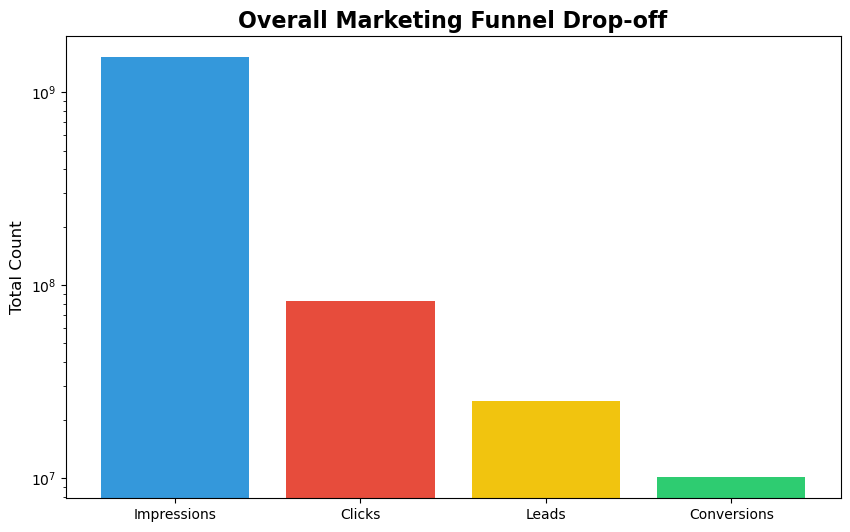

In [3]:
import matplotlib.pyplot as plt

funnel_stages = ['Impressions', 'Clicks', 'Leads', 'Conversions']
funnel_totals = df[funnel_stages].sum()

plt.figure(figsize=(10, 6))
plt.bar(funnel_stages, funnel_totals, color=['#3498db', '#e74c3c', '#f1c40f', '#2ecc71'])

plt.title('Overall Marketing Funnel Drop-off', fontsize=16, fontweight='bold')
plt.ylabel('Total Count', fontsize=12)

plt.yscale('log') 

# Display the chart
plt.show()

# Executive Summary: Marketing Campaign ROI & Funnel Analysis (Task 4)

### 1. Project Objective & Data Cleaning
The objective of this Exploratory Data Analysis (EDA) was to move beyond predictive modeling and focus on the **"Why"** behind customer behavior and marketing performance. The raw dataset (10,000+ campaigns) was first audited and cleaned (handling null values and checking data types) to ensure accurate financial calculations. 

### 2. Visualizing the Funnel (The "Why")
By visualizing the entire customer journey (Impressions ➡️ Clicks ➡️ Leads ➡️ Conversions), a major bottleneck was identified at the top of the funnel. 
* **The Insight:** The steepest drop-off occurs between **Impressions and Clicks**. We are successfully getting millions of eyes on our campaigns, but the audience is not engaging. 
* **The "Why":** This indicates that the core issue is not reach, but rather ad relevance and copy. Once a user clicks, the progression from Lead to Conversion stabilizes significantly.

### 3. Financial Analysis (ROI by Channel)
To determine the most profitable use of marketing funds, Return on Investment (ROI) was aggregated and calculated mathematically `((Revenue - Cost) / Cost * 100)` for each channel:
* **Top Performer:** **Search Marketing** leads the business with an ROI of **101.31%**.
* **Underperformer:** **Social Marketing** is lagging at the bottom with an ROI of **97.66%**.

### 4. Strategic Budget Recommendations
Based on the EDA and ROI calculations, I recommend the following actionable steps to leadership:
1. **Reallocate Budget based on ROI:** Shift 15% of the upcoming marketing budget away from **Social** channels and inject it directly into **Search** campaigns to maximize immediate revenue.
2. **Optimize for the Bottleneck:** Freeze spending on "Top of Funnel" metrics (buying Impressions). Instead, reallocate those funds into A/B testing ad copy and graphics to improve the Click-Through Rate (CTR) and solve the primary funnel drop-off.
